In [30]:
import pandas as pd

In [31]:
data=pd.read_excel("Scraped_Zameen_Data.xlsx",usecols=["City","Type","Area","Price","Purpose","Location","Description","Bedrooms","Bathrooms","Kitchens"])

In [32]:
data.iloc[:,0:3]

,City,Type,Area
0,Karachi,Flat,128 Sq. Yd.
1,Karachi,Flat,161 Sq. Yd.
2,Karachi,Flat,111 Sq. Yd.
3,Karachi,Flat,106 Sq. Yd.
4,Karachi,Flat,156 Sq. Yd.
...,...,...,...
18250,Nowshera,House,10 Marla
18251,Okara,House,2 Marla
18252,Okara,House,8 Marla
18253,Attock,House,1 Kanal


In [33]:
data["Area"]=data["Area"].str.replace("Sq. Yd.","Sq.Yd.")

In [34]:
data["Area"].str.split(" ",expand=True )

,0,1
0,128,Sq.Yd.
1,161,Sq.Yd.
2,111,Sq.Yd.
3,106,Sq.Yd.
4,156,Sq.Yd.
...,...,...
18250,10,Marla
18251,2,Marla
18252,8,Marla
18253,1,Kanal


In [35]:
data["Area_Value"]=data["Area"].str.split(" ",expand=True)[0]

In [36]:
data["Area_Unit"]=data["Area"].str.split(" ",expand=True )[1]

In [37]:
data["Area_Value"]=data["Area_Value"].str.replace(",","").astype(float)

In [38]:
convesrion={
    "Sq.Yd.":0.836127,
    "Marla":25.2929,
    "Kanal":505.857, 
}

data["Conversion_Factor"]=data["Area_Unit"].map(convesrion)

In [39]:
data["Areea_in_Sq_Yd"]=data["Area_Value"]*data["Conversion_Factor"]

In [40]:
data

,City,Type,Area,Price,Purpose,Location,Description,Bedrooms,Bathrooms,Kitchens,Area_Value,Area_Unit,Conversion_Factor,Areea_in_Sq_Yd
0,Karachi,Flat,128 Sq.Yd.,PKR\n4.75 Crore,For Sale,"DHA Defence, Karachi, Sindh",SAIMA MARINA RESIDENCE HMR WATERFRONT\nINVESTO...,2,2,NaN,128.0,Sq.Yd.,0.836127,107.024256
1,Karachi,Flat,161 Sq.Yd.,PKR\n6.25 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n2 B...,2,3,1.0,161.0,Sq.Yd.,0.836127,134.616447
2,Karachi,Flat,111 Sq.Yd.,PKR\n3.45 Crore,For Sale,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n1 B...,1,2,NaN,111.0,Sq.Yd.,0.836127,92.810097
3,Karachi,Flat,106 Sq.Yd.,PKR\n2.98 Crore,For Sale,"DHA Defence, Karachi, Sindh",Chance Deal at HMR Waterfront 1-Bed Apartment ...,1,2,4.0,106.0,Sq.Yd.,0.836127,88.629462
4,Karachi,Flat,156 Sq.Yd.,PKR\n4.65 Crore,For Sale,"DHA Defence, Karachi, Sindh",HMR WATERFRONT \n\nOwn Your Dream Apartment in...,2,2,NaN,156.0,Sq.Yd.,0.836127,130.435812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18250,Nowshera,House,10 Marla,PKR\n40 Thousand,For,"Armour Colony, Nowshera, Khyber Pakhtunkhwa",Malik Real Estate and Builders Take your pick ...,5,5,2.0,10.0,Marla,25.292900,252.929000
18251,Okara,House,2 Marla,PKR\n14 Thousand,For,"Shah Din Road, Okara, Punjab",NaN,2,2,1.0,2.0,Marla,25.292900,50.585800
18252,Okara,House,8 Marla,PKR\n40 Thousand,For,"Umer Din Town, Okara, Punjab",8 Marla Single Story House Is Available For I...,3,3,2.0,8.0,Marla,25.292900,202.343200
18253,Attock,House,1 Kanal,PKR\n1 Lakh,For,"Cantt, Attock, Punjab",NaN,6,5,1.0,1.0,Kanal,505.857000,505.857000


In [44]:
data["City"]=data["City"].str.strip().str.title()

In [46]:
def see_null_values(collection):
    for col in collection:
        print(f"{col} has {collection[col].nunique()} unique values")
        print(f"{collection[col].unique}")
        print("\n----------------------------------------------------")

In [48]:
see_null_values(data)

City has 57 unique values
<bound method Series.unique of 0                Karachi
1                Karachi
2                Karachi
3                Karachi
4                Karachi
              ...       
18250           Nowshera
18251              Okara
18252              Okara
18253             Attock
18254    Dera Ghazi Khan
Name: City, Length: 18255, dtype: object>

----------------------------------------------------
Type has 7 unique values
<bound method Series.unique of 0         Flat
1         Flat
2         Flat
3         Flat
4         Flat
         ...  
18250    House
18251    House
18252    House
18253    House
18254    House
Name: Type, Length: 18255, dtype: object>

----------------------------------------------------
Area has 468 unique values
<bound method Series.unique of 0        128 Sq.Yd.
1        161 Sq.Yd.
2        111 Sq.Yd.
3        106 Sq.Yd.
4        156 Sq.Yd.
            ...    
18250      10 Marla
18251       2 Marla
18252       8 Marla
18253       1 Kan

In [50]:
def see_null_values(collection):
    for col in collection:
        print(f"{col} has {collection[col].isnull().sum()} null values")
        print(f"{data.loc[collection[col].isnull()]}")
        print("\n---------------------------------------------------------")

In [61]:
see_null_values(data)

City has 0 null values
Empty DataFrame
Columns: [City, Type, Area, Price, Purpose, Location, Description, Bedrooms, Bathrooms, Kitchens, Area_Value, Area_Unit, Conversion_Factor, Areea_in_Sq_Yd]
Index: []

---------------------------------------------------------
Type has 0 null values
Empty DataFrame
Columns: [City, Type, Area, Price, Purpose, Location, Description, Bedrooms, Bathrooms, Kitchens, Area_Value, Area_Unit, Conversion_Factor, Areea_in_Sq_Yd]
Index: []

---------------------------------------------------------
Area has 16 null values
             City   Type Area Price   Purpose  \
683       Karachi  House  NaN   NaN  For Sale   
2178    Islamabad  House  NaN   NaN  For Sale   
2447    Islamabad  House  NaN   NaN  For Sale   
2469    Islamabad  House  NaN   NaN  For Sale   
2748   Faisalabad  House  NaN   NaN  For Sale   
3215   Faisalabad  House  NaN   NaN  For Sale   
3764       Multan  House  NaN   NaN  For Sale   
3787       Multan  House  NaN   NaN  For Sale   
4165   

In [54]:
data["Purpose"].replace("For ","For Rent",inplace=True)

In [57]:
data["Description"]=data["Description"].str.strip().str.title()

In [111]:
categorical_data=["City","Type","Location","Purpose","Description","Area_Unit"]

for col in categorical_data:
    data[col]=data[col].fillna(data[col].mode()[0])

In [63]:
data.drop("Area",axis=1,inplace=True)

In [65]:
data.drop_duplicates(inplace=True)

In [75]:
data["Bedrooms"]=data["Bedrooms"].str.replace("-","").str.replace(",","")

In [79]:
data["Bedrooms"]=pd.to_numeric(data["Bedrooms"])

In [85]:
data["Bathrooms"]=data["Bathrooms"].str.replace("-","").str.replace(",","")
data["Bathrooms"]=pd.to_numeric(data["Bathrooms"])

In [88]:
data["Price"]

0         PKR\n4.75 Crore
1         PKR\n6.25 Crore
2         PKR\n3.45 Crore
3         PKR\n2.98 Crore
4         PKR\n4.65 Crore
               ...       
18250    PKR\n40 Thousand
18251    PKR\n14 Thousand
18252    PKR\n40 Thousand
18253         PKR\n1 Lakh
18254    PKR\n60 Thousand
Name: Price, Length: 17715, dtype: object

In [90]:
data["Price"]=data["Price"].str.replace("PKR\n","")


In [91]:
data["Price_Value"]=data["Price"].str.split(" ",expand=True)[0]
data["Price_Unit"]=data["Price"].str.split(" ",expand=True)[1]

In [92]:
conversion={
    "Thousand":1000,
    "Lakh":1000000,
    "Crore":1000000000
}

data["Price_Value_Unit"]=data["Price_Unit"].map(conversion)

In [96]:
data["Price_Value"]=data["Price_Value"].astype("float")

In [97]:
data.columns


Index(['City', 'Type', 'Price', 'Purpose', 'Location', 'Description',
       'Bedrooms', 'Bathrooms', 'Kitchens', 'Area_Value', 'Area_Unit',
       'Conversion_Factor', 'Areea_in_Sq_Yd', 'Price_Value', 'Price_Unit',
       'Price_Value_Unit'],
      dtype='object')

In [98]:
data["Price"]=data["Price_Value"]*data["Price_Value_Unit"]

In [105]:
data

,City,Type,Price,Purpose,Location,Description,Bedrooms,Bathrooms,Kitchens,Area_Value,Area_Unit,Conversion_Factor,Areea_in_Sq_Yd
0,Karachi,Flat,4.750000e+09,For Sale,"DHA Defence, Karachi, Sindh",Saima Marina Residence Hmr Waterfront\nInvesto...,2.0,2.0,NaN,128.0,Sq.Yd.,0.836127,107.024256
1,Karachi,Flat,6.250000e+09,For Sale,"DHA Defence, Karachi, Sindh",Live The Seafront Dream At H&S Residence \n2 B...,2.0,3.0,1.0,161.0,Sq.Yd.,0.836127,134.616447
2,Karachi,Flat,3.450000e+09,For Sale,"DHA Defence, Karachi, Sindh",Live The Seafront Dream At H&S Residence \n1 B...,1.0,2.0,NaN,111.0,Sq.Yd.,0.836127,92.810097
3,Karachi,Flat,2.980000e+09,For Sale,"DHA Defence, Karachi, Sindh",Chance Deal At Hmr Waterfront 1-Bed Apartment ...,1.0,2.0,4.0,106.0,Sq.Yd.,0.836127,88.629462
4,Karachi,Flat,4.650000e+09,For Sale,"DHA Defence, Karachi, Sindh",Hmr Waterfront \n\nOwn Your Dream Apartment In...,2.0,2.0,NaN,156.0,Sq.Yd.,0.836127,130.435812
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18250,Nowshera,House,4.000000e+04,For Rent,"Armour Colony, Nowshera, Khyber Pakhtunkhwa",Malik Real Estate And Builders Take Your Pick ...,NaN,NaN,2.0,10.0,Marla,25.292900,252.929000
18251,Okara,House,1.400000e+04,For Rent,"Shah Din Road, Okara, Punjab",Marriott Estate And Builders Offer A Ideal Hou...,NaN,NaN,1.0,2.0,Marla,25.292900,50.585800
18252,Okara,House,4.000000e+04,For Rent,"Umer Din Town, Okara, Punjab",8 Marla Single Story House Is Available For I...,NaN,NaN,2.0,8.0,Marla,25.292900,202.343200
18253,Attock,House,1.000000e+06,For Rent,"Cantt, Attock, Punjab",Marriott Estate And Builders Offer A Ideal Hou...,NaN,NaN,1.0,1.0,Kanal,505.857000,505.857000


In [104]:
data=data.drop(["Price_Value","Price_Unit","Price_Value_Unit"],axis=1)


In [112]:
data.dtypes

City                  object
Type                  object
Price                float64
Purpose               object
Location              object
Description           object
Bedrooms             float64
Bathrooms            float64
Kitchens             float64
Area_Value           float64
Area_Unit             object
Conversion_Factor    float64
Areea_in_Sq_Yd       float64
dtype: object

In [113]:
data.isnull().sum()

City                 0
Type                 0
Price                0
Purpose              0
Location             0
Description          0
Bedrooms             0
Bathrooms            0
Kitchens             0
Area_Value           0
Area_Unit            0
Conversion_Factor    0
Areea_in_Sq_Yd       0
dtype: int64

In [109]:
numerical_data=["Price","Bedrooms","Bathrooms","Kitchens","Area_Value","Conversion_Factor","Areea_in_Sq_Yd"]

for col in numerical_data:
    data[col]=data[col].fillna(data[col].mean())

In [127]:
float_data=["Bathrooms","Bedrooms","Kitchens"]

for col in float_data:
    data[col]=data[col].astype(int)

In [140]:
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [141]:
import matplotlib.pyplot as plt

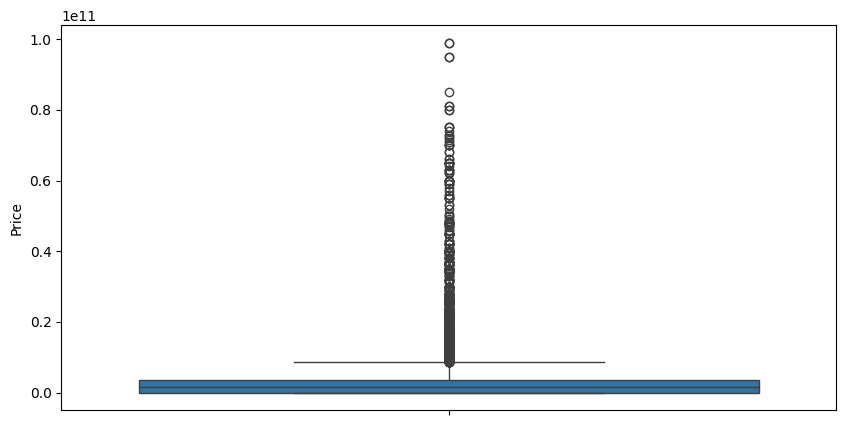

In [152]:
plt.figure(figsize=(10,5))

sns.boxplot(y=data["Price"])
plt.xticks(rotation=90)
plt.show()

In [154]:
price_per_city=data.groupby("City")["Price"].sum().sort_values(ascending=False)

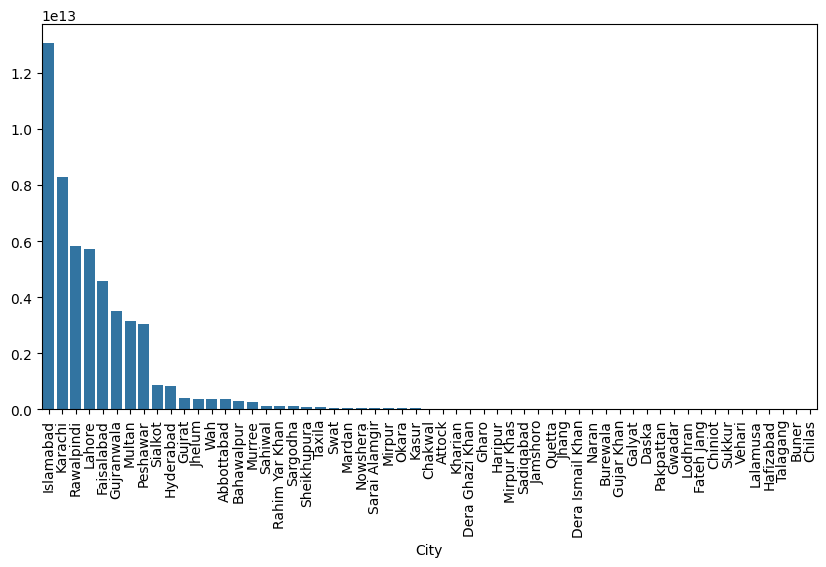

In [159]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=price_per_city.index,
    y=price_per_city.values
)
plt.xticks(rotation=90)
plt.show()

In [160]:
data["Bedrooms"].unique()

array([ 2,  1,  3,  9,  6,  5,  4, 11,  8,  7, 10])

In [162]:
data["Room_Size"]=pd.cut(
    data["Bedrooms"],
    bins=[0,3,8,10],
    labels=["Small","Medium","Large"],
    right=True
)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'House'),
  Text(1, 0, 'Flat'),
  Text(2, 0, 'Upper Portion'),
  Text(3, 0, 'Lower Portion'),
  Text(4, 0, 'Farm House'),
  Text(5, 0, 'Room'),
  Text(6, 0, 'Penthouse')])

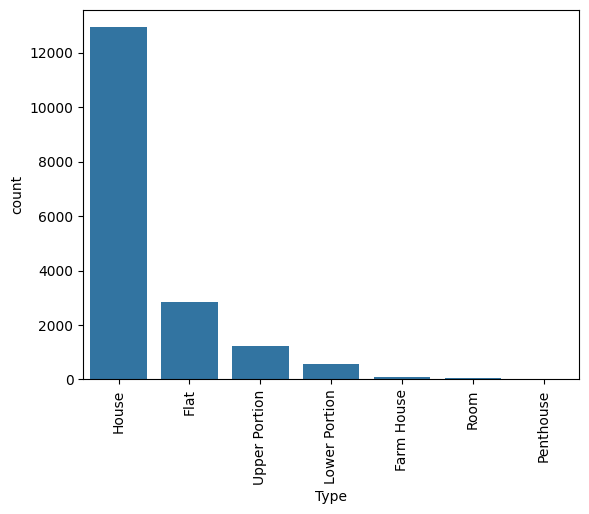

In [187]:
sns.countplot(
    data,
    x="Type",
    order=data["Type"].value_counts().index
    )

plt.xticks(rotation=90)